# Transfer Learning: UrbanSound8K → SONYC

This notebook adapts the UrbanSound8K CNN to the SONYC dataset using transfer learning.

Objectives:

- Load the pretrained CNN
- Freeze feature extraction layers
- Replace the classifier
- Fine-tune on SONYC
- Save the adapted model

In [1]:
# Mount Google Drive

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Import libraries

from pathlib import Path

import numpy as np
import pandas as pd
import librosa

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

In [3]:
# Project paths

PROJECT = Path("/content/drive/MyDrive/UrbanNoiseProject")

MODEL_DIR = PROJECT / "models"

DATA_DIR = PROJECT / "datasets"

LABELS = DATA_DIR / "processed" / "sonyc_labels.csv"

In [4]:
# Load mapped SONYC labels

df = pd.read_csv(LABELS)

df.head()

,split,audio_filename,1_engine_presence,2_machinery-impact_presence,3_non-machinery-impact_presence,4_powered-saw_presence,5_alert-signal_presence,6_music_presence,7_human-voice_presence,8_dog_presence,class,filepath
0,validate,00_000066.wav,1,1,1,1,1,1,1,1,Construction,/content/drive/MyDrive/UrbanNoiseProject/datas...
1,validate,00_000118.wav,0,0,0,0,0,0,1,0,Worship,/content/drive/MyDrive/UrbanNoiseProject/datas...
2,validate,00_000275.wav,1,0,1,0,0,0,0,0,Traffic,/content/drive/MyDrive/UrbanNoiseProject/datas...
3,validate,00_000277.wav,0,0,0,0,1,0,0,0,Traffic,/content/drive/MyDrive/UrbanNoiseProject/datas...
4,validate,00_000357.wav,1,0,0,0,0,0,0,0,Traffic,/content/drive/MyDrive/UrbanNoiseProject/datas...


In [5]:
def preprocess_audio(path):

    audio, sr = librosa.load(path, sr=22050)

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )

    mel = librosa.power_to_db(
        mel,
        ref=np.max
    )

    if mel.shape[1] < 128:

        pad = 128 - mel.shape[1]

        mel = np.pad(
            mel,
            ((0,0),(0,pad))
        )

    else:

        mel = mel[:,:128]

    return mel

In [6]:
X = []
y = []

for _, row in df.iterrows():

    try:

        feature = preprocess_audio(
            row["filepath"]
        )

        X.append(feature)

        y.append(row["class"])

    except:

        continue

X = np.array(X)

X = X[..., np.newaxis]

print(X.shape)

(3068, 128, 128, 1)


In [17]:
# Build SONYC spectrogram dataset

import librosa
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# Load mapped labels
labels = pd.read_csv(
    LABELS # Use the LABELS variable for the correct path
)

print("Mapped samples:", len(labels))
print(labels["class"].value_counts()) # Corrected 'label' to 'class'

Mapped samples: 3068
class
Traffic          1085
Ambience          970
Worship           472
Construction      463
Entertainment      78
Name: count, dtype: int64


In [18]:
# ============================================================
# Convert audio to 128x128 Mel Spectrogram
# ============================================================

def preprocess_audio(audio_path):

    audio, sr = librosa.load(
        audio_path,
        sr=22050
    )

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    if mel_db.shape[1] < 128:

        pad = 128 - mel_db.shape[1]

        mel_db = np.pad(
            mel_db,
            ((0,0),(0,pad))
        )

    else:

        mel_db = mel_db[:, :128]

    return mel_db

In [21]:
# ============================================================
# Build SONYC Dataset
# ============================================================

X = []
y = []

for _, row in tqdm(labels.iterrows(), total=len(labels)):

    # Use the 'filepath' column directly, as it contains the full path
    audio_path = Path(row["filepath"])

    if not audio_path.exists():
        continue

    try:

        mel = preprocess_audio(audio_path)

        X.append(mel)

        y.append(row["class"]) # Corrected 'label' to 'class'

    except Exception:
        continue


X = np.array(X)
y = np.array(y)

print()

print("Dataset built successfully")
print("X shape:", X.shape)
print("y shape:", y.shape)

100%|██████████| 3068/3068 [02:20<00:00, 21.82it/s]



Dataset built successfully
X shape: (3068, 128, 128)
y shape: (3068,)


In [22]:
# ============================================================
# Encode labels
# ============================================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(encoder.classes_)

['Ambience' 'Construction' 'Entertainment' 'Traffic' 'Worship']


In [23]:
# Prepare input shape
X_sonyc = np.expand_dims(X, axis=-1)

print("Input shape:", X_sonyc.shape)

Input shape: (3068, 128, 128, 1)


In [24]:
# Split dataset
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_sonyc,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_val.shape)

(2454, 128, 128, 1)
(614, 128, 128, 1)


In [26]:
from tensorflow.keras.models import load_model

base_model = load_model(
    MODEL_DIR / "urban_noise_cnn.keras" # Corrected PROJECT_DIR to MODEL_DIR
)

print("UrbanSound8K model loaded.")

UrbanSound8K model loaded.


In [27]:
# Build transfer learning model

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input

# Explicit input layer
inputs = Input(shape=(128, 128, 1))

# Pass through every layer except the last Dense classifier
x = inputs
for layer in base_model.layers[:-1]:
    layer.trainable = False
    x = layer(x)

# New classifier for Kigali classes
outputs = Dense(
    5,
    activation="softmax",
    name="sonyc_classifier"
)(x)

transfer_model = Model(inputs=inputs, outputs=outputs)

transfer_model.summary()

Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sonyc_classifier (Dense)        │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,829 (429.02 KB)

 Trainable params: 645 (2.52 KB)

 Non-trainable params: 109,184 (426.50 KB)

In [28]:
from tensorflow.keras.optimizers import Adam

transfer_model.compile(

    optimizer=Adam(1e-4),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [29]:
# Train SONYC classifier

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

history = transfer_model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=25,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1

)

Epoch 1/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 26s 323ms/step - accuracy: 0.1137 - loss: 1.9293 - val_accuracy: 0.1026 - val_loss: 1.7949
Epoch 2/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 41s 331ms/step - accuracy: 0.1410 - loss: 1.7772 - val_accuracy: 0.1205 - val_loss: 1.6636
Epoch 3/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 23s 297ms/step - accuracy: 0.1548 - loss: 1.6657 - val_accuracy: 0.1319 - val_loss: 1.5683
Epoch 4/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 43s 327ms/step - accuracy: 0.2050 - loss: 1.5880 - val_accuracy: 0.1954 - val_loss: 1.4999
Epoch 5/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 41s 329ms/step - accuracy: 0.2376 - loss: 1.5308 - val_accuracy: 0.3225 - val_loss: 1.4534
Epoch 6/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 42s 338ms/step - accuracy: 0.2783 - loss: 1.4967 - val_accuracy: 0.3811 - val_loss: 1.4208
Epoch 7/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 24s 311ms/step - accuracy: 0.3183 - loss: 1.4567 - val_accuracy: 0.3876 - val_loss: 1.3963
Epoch 8/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 40s 303ms/step - accuracy: 0.3289 - loss: 1.4386 - val_accu

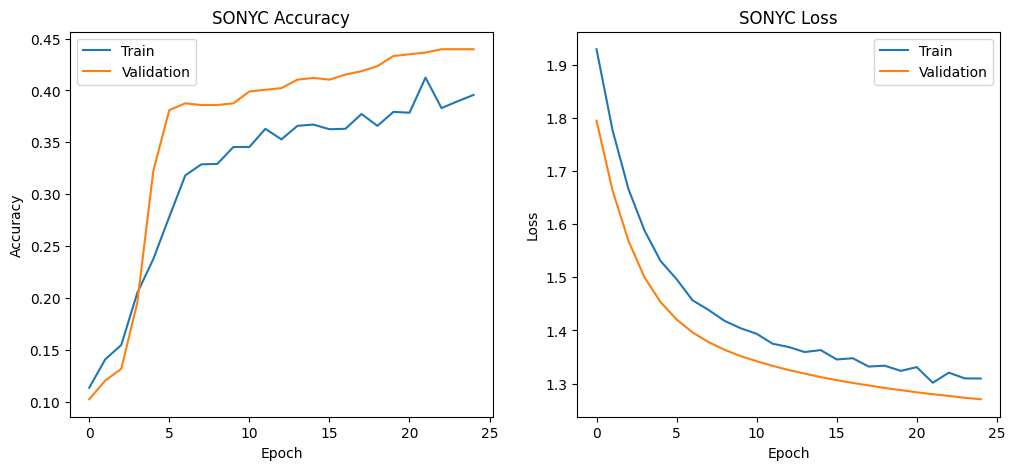

In [30]:
# Plot training curves

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("SONYC Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.title("SONYC Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [31]:
# Evaluate SONYC model

loss, accuracy = transfer_model.evaluate(

    X_val,
    y_val,
    verbose=0

)

print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.4397


In [33]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/UrbanNoiseProject")
MODELS_DIR = PROJECT_DIR / "models"

In [34]:
# Save SONYC model

transfer_model.save(

    PROJECT_DIR / "models/urban_noise_sonyc.keras"

)

print("SONYC model saved.")

SONYC model saved.
